# Additional Preprocessing

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from utils import horizontal
all_55000_steam = pd.read_csv("data/all_55000_steam.csv", low_memory=False)
plt.style.use("ggplot")
# all_55000_steam = all_55000_steam.drop(['website', 'header_image'])

# Feature Engineering

In [3]:
# Categorizing Price
import pandas as pd
bins = [-1, 0, 10, 50, float('inf')]  # -1 to include 0 in the first bin
labels = ['Free to Play', 'Under $10', '$10-50', 'Over $50']
all_55000_steam['price_category'] = pd.cut(all_55000_steam['price'], bins=bins, labels=labels)

# Creating a total review counts feature
all_55000_steam['total_review_count'] = all_55000_steam['positive_reviews'] + all_55000_steam['negative_reviews']

# Categorizing total review counts
bins = [-1, 0, 10, 100, 1000, float('inf')]
labels = []

# Estimating the "review_score" (out of 100) for the game based on the review counts

# Creating a revenue estimation using initial_price, price, and review counts


# Basic Stats

In [4]:
horizontal([all_55000_steam.describe(), all_55000_steam[all_55000_steam.drop(['website', 'header_image'], axis=1).select_dtypes(include=['object', 'category']).columns].describe()])

# Review Scores

# Owners

# Genres

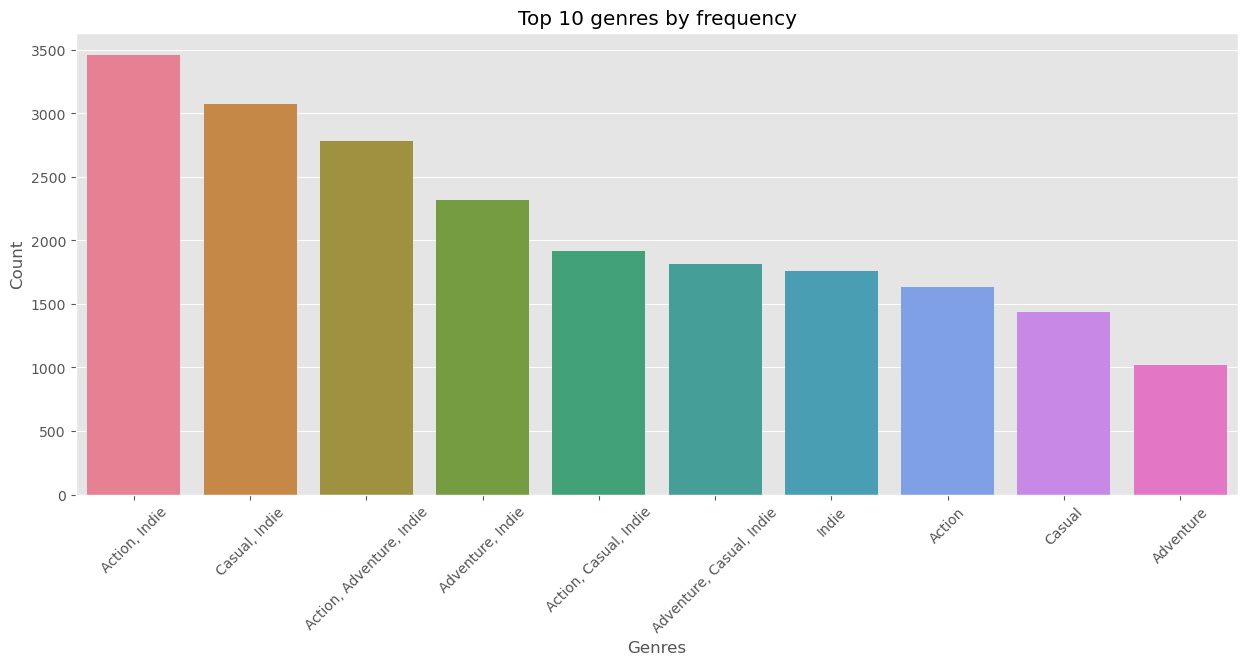

In [26]:
def plot_top_n_genres_distribution(n = 10):
    genre_frequencies = pd.DataFrame(
        {
            'genres': all_55000_steam['genres'].value_counts().index,
            'count': all_55000_steam['genres'].value_counts().values
        }
    )
    genre_frequencies
    top_genre_frequencies = genre_frequencies.head(n)

    fig = plt.figure(figsize=(15, 6))
    sns.barplot(
        data=top_genre_frequencies,
        x='genres',
        y='count',
        hue='genres',
        dodge=False,
    )
    plt.title(f"Top {n} genres by frequency")
    plt.xlabel("Genres")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    return fig
    # return top_genre_frequences

fig = plot_top_n_genres_distribution()

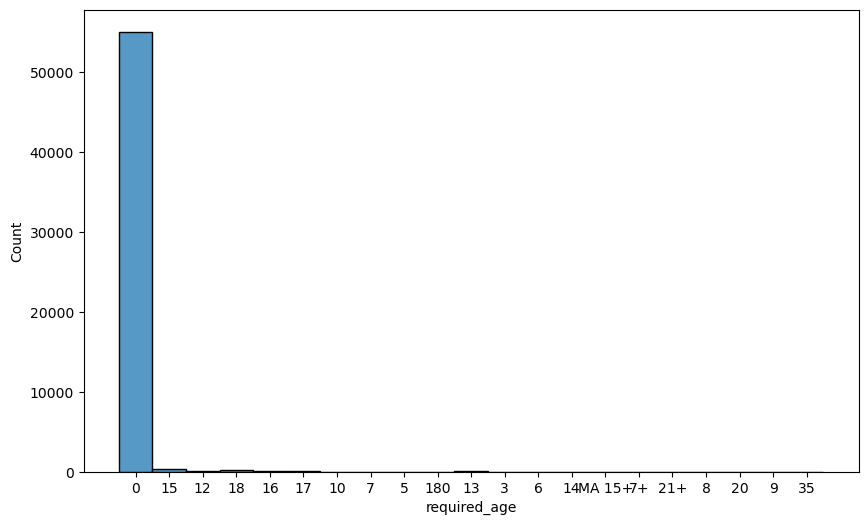

In [5]:
# Price Distribution of the market
def plot_price_distribution():
    plt.figure(figsize=(10,6))
    sns.histplot(
        data = all_55000_steam,
        x='price_category',
    )
    plt.show()

def plot_review_distributions():
    plt.figure(figsize=(10, 6))
    sns.histplot(
        data = all_55000_steam,
        x='required_age',
        bins=100
    )
    plt.show()

plot_review_distributions()

HUGE outliers, choosing to bin and lump.